Prediksi Risiko Diabetes Menggunakan Deep Learning dengan Model Artificial Neural Network (ANN)

In [ ]:
# Install library jika belum tersedia
!pip install tensorflow scikit-learn matplotlib seaborn pandas numpy

# Import semua library yang dibutuhkan
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import classification_report, confusion_matrix
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.regularizers import l2
from tensorflow.keras.callbacks import EarlyStopping
import os



In [ ]:
# Ganti path sesuai lokasi dataset di Google Drive
dataset_path = '/content/Diabetes-NHANESDataset.csv'

df = pd.read_csv(dataset_path)
print("Ukuran data:", df.shape)
df.head()

Ukuran data: (52390, 45)


,SEQN,SEQN_new,SDDSRVYR,LBDINSI,LBXGLU,LBXGLUSI,LBXIN,LBXSGL,LBXCP,VNLDHDLRATIO,...,AAPSI,LBDAPBSI,LBXAPB,BPXCHR,VNAVEBPXSY,LBXSCH,LBXSTR,LBXTC,LBXTR,Target
0,3,I-3,-1,55.92,106.000,5.88400,9.32,99.0,0.540,NaN,...,1.36,1.460,146.0,NaN,120.000000,271.0,NaN,268.0,174.0,0
1,4,I-4,-1,35.82,88.900,4.93500,5.97,88.0,0.337,NaN,...,1.51,0.780,78.0,NaN,124.666667,159.0,NaN,160.0,84.0,0
2,9,I-9,-1,60.84,130.525,7.24525,10.14,110.0,0.695,2.44,...,1.66,1.135,113.5,NaN,130.333333,236.0,NaN,236.0,104.5,0
3,10,I-10,-1,34.62,85.500,4.74600,5.77,85.0,0.509,NaN,...,1.25,1.180,118.0,NaN,128.000000,222.0,115.0,225.0,109.0,0
4,11,I-11,-1,290.94,271.700,15.08200,48.49,263.0,0.211,NaN,...,1.55,1.450,145.0,NaN,119.777778,260.0,90.0,260.0,94.0,1


In [ ]:
# Cek missing values
print("Jumlah missing value per kolom:\n", df.isnull().sum())

# Isi missing values dengan median
df = df.fillna(df.median(numeric_only=True))

# Deteksi dan tangani redundansi
if {'Glucose','Insulin'}.issubset(df.columns):
    df['GlucoseInsulin_mean'] = (df['Glucose'] + df['Insulin']) / 2
    df['GlucoseInsulin_diff2'] = abs(df['Glucose'] - df['Insulin']) / 2
    df.drop(['Glucose','Insulin'], axis=1, inplace=True)

if {'SkinThickness','BMI'}.issubset(df.columns):
    df['SkinBMI_mean'] = (df['SkinThickness'] + df['BMI']) / 2
    df['SkinBMI_diff2'] = abs(df['SkinThickness'] - df['BMI']) / 2
    df.drop(['SkinThickness','BMI'], axis=1, inplace=True)

# Pisahkan fitur dan target
target_col = None
for col in df.columns:
    if df[col].nunique() == 2 or col.lower() in ['diabetes','outcome','label']:
        target_col = col
        break

if target_col is None:
    raise ValueError("Tidak ditemukan kolom target biner (0/1). Harap tentukan manual!")

print(f"Kolom target terdeteksi: {target_col}")

X = df.drop(columns=[target_col])
y = df[target_col]


Jumlah missing value per kolom:
 SEQN                0
SEQN_new            0
SDDSRVYR            0
LBDINSI          5907
LBXGLU           5768
LBXGLUSI        27025
LBXIN            5907
LBXSGL           2366
LBXCP           27082
VNLDHDLRATIO    15998
VNTOTHDRATIO     1795
LBDHDD           1788
LBDHDDSI         1786
LBDLDL          15998
LBDLDLSI        15971
LBDSCHSI         2363
LBDSTRSI         6313
BMXWAIST         2944
BMXSAD1         43034
BMXSUB          19406
BMXBMI           1263
BMPWHR          36543
VNLBAVEBPXDI     2966
LBDSBUSI         2363
LBXSBU           2363
LBXSC3SI         2392
LBDSTBSI         2374
LBXSTB           2373
LBXSATSI         2392
LBDSALSI         2359
LBXSAL           2359
URXUMA           2153
URXUMS          18048
LBXSAPSI         2365
AAP             44537
AAPSI           44537
LBDAPBSI        26362
LBXAPB          26362
BPXCHR          52091
VNAVEBPXSY       2506
LBXSCH           2363
LBXSTR           6314
LBXTC            1684
LBXTR            5623

In [ ]:
X = X.drop(columns=['SEQN_new'])

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# PCA untuk menggabungkan fitur redundan
pca = PCA(n_components=5)
X_pca = pca.fit_transform(X_scaled)
print("Dimensi setelah PCA:", X_pca.shape)

Dimensi setelah PCA: (52390, 5)


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X_pca, y, test_size=0.2, random_state=42, stratify=y)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/100
1310/1310 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.7918 - loss: 0.4512 - val_accuracy: 0.8342 - val_loss: 0.3931
Epoch 2/100
1310/1310 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.8354 - loss: 0.3950 - val_accuracy: 0.8408 - val_loss: 0.3832
Epoch 3/100
1310/1310 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.8458 - loss: 0.3754 - val_accuracy: 0.8468 - val_loss: 0.3747
Epoch 4/100
1310/1310 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.8463 - loss: 0.3727 - val_accuracy: 0.8496 - val_loss: 0.3708
Epoch 5/100
1310/1310 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.8440 - loss: 0.3741 - val_accuracy: 0.8441 - val_loss: 0.3732
Epoch 6/100
1310/1310 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.8467 - loss: 0.3683 - val_accuracy: 0.8483 - val_loss: 0.3674
Epoch 7/100
1310/1310 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.8476 - loss: 0.3673 - val_accuracy: 0.8458 - val_loss: 0.3684
Epoch 8/100
1310/1310 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.8471 - loss: 0

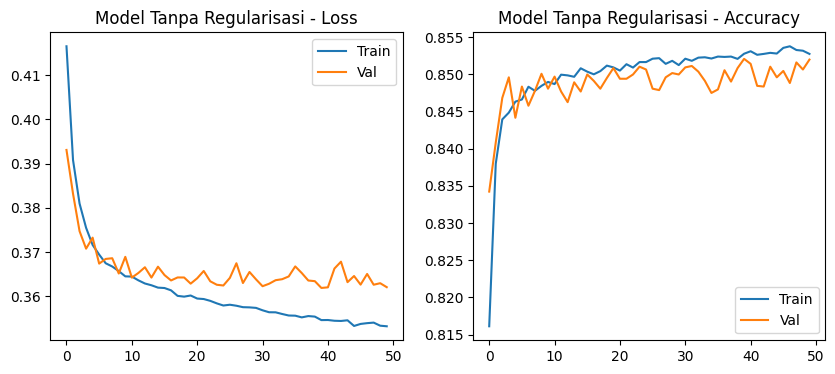

328/328 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
              precision    recall  f1-score   support

           0       0.87      0.96      0.91      8244
           1       0.74      0.47      0.58      2234

    accuracy                           0.85     10478
   macro avg       0.81      0.71      0.74     10478
weighted avg       0.84      0.85      0.84     10478



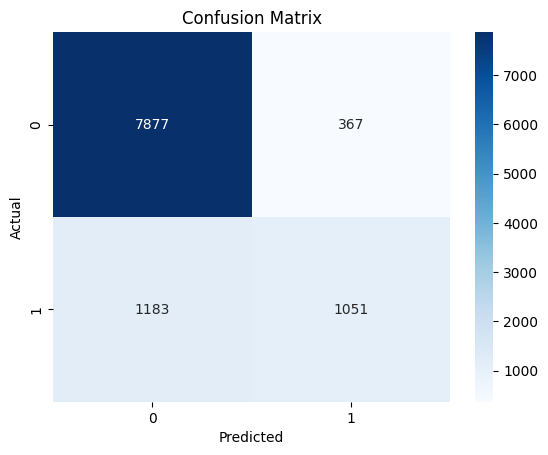

In [ ]:
model_plain = Sequential([
    Dense(64, activation='relu', input_shape=(X_train.shape[1],)),
    Dense(32, activation='relu'),
    Dense(1, activation='sigmoid')
])

model_plain.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
es = EarlyStopping(patience=10, restore_best_weights=True)

history_plain = model_plain.fit(
    X_train, y_train, validation_data=(X_test, y_test),
    epochs=100, batch_size=32, callbacks=[es], verbose=1)

plot_training(history_plain, "Model Tanpa Regularisasi")
evaluate_model(model_plain, X_test, y_test)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/100
1310/1310 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.7971 - loss: 0.4880 - val_accuracy: 0.8219 - val_loss: 0.4226
Epoch 2/100
1310/1310 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.8211 - loss: 0.4220 - val_accuracy: 0.8401 - val_loss: 0.4058
Epoch 3/100
1310/1310 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.8403 - loss: 0.4050 - val_accuracy: 0.8425 - val_loss: 0.3952
Epoch 4/100
1310/1310 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.8444 - loss: 0.3943 - val_accuracy: 0.8421 - val_loss: 0.3939
Epoch 5/100
1310/1310 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.8425 - loss: 0.3937 - val_accuracy: 0.8428 - val_loss: 0.3905
Epoch 6/100
1310/1310 ━━━━━━━━━━━━━━━━━━━━ 11s 7ms/step - accuracy: 0.8442 - loss: 0.3944 - val_accuracy: 0.8421 - val_loss: 0.3860
Epoch 7/100
1310/1310 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.8443 - loss: 0.3869 - val_accuracy: 0.8441 - val_loss: 0.3841
Epoch 8/100
1310/1310 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.8504 - loss: 

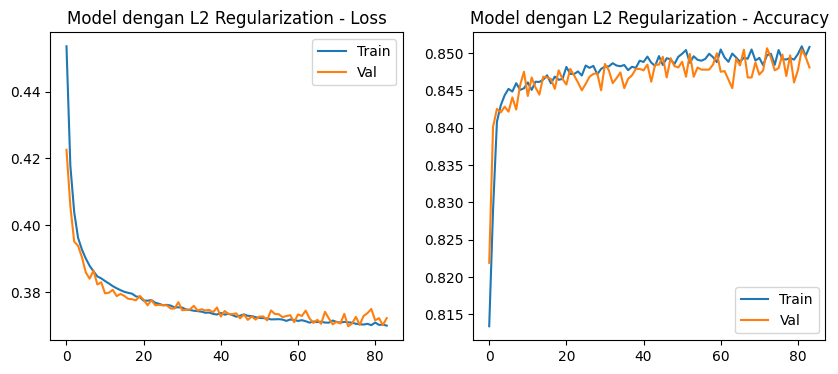

328/328 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
              precision    recall  f1-score   support

           0       0.86      0.96      0.91      8244
           1       0.75      0.44      0.56      2234

    accuracy                           0.85     10478
   macro avg       0.81      0.70      0.73     10478
weighted avg       0.84      0.85      0.83     10478



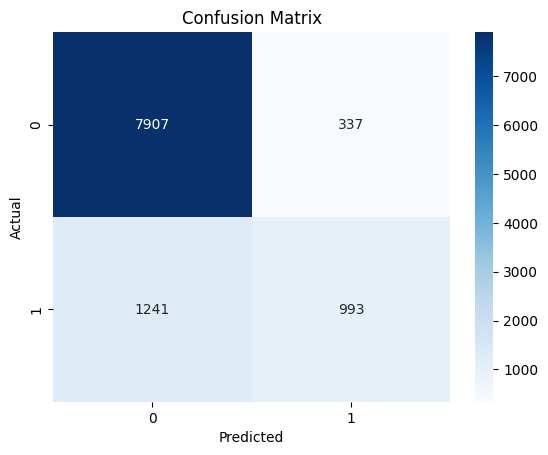

In [ ]:
model_l2 = Sequential([
    Dense(64, activation='relu', kernel_regularizer=l2(0.001), input_shape=(X_train.shape[1],)),
    Dense(32, activation='relu', kernel_regularizer=l2(0.001)),
    Dense(1, activation='sigmoid')
])

model_l2.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
history_l2 = model_l2.fit(
    X_train, y_train, validation_data=(X_test, y_test),
    epochs=100, batch_size=32, callbacks=[es], verbose=1)

plot_training(history_l2, "Model dengan L2 Regularization")
evaluate_model(model_l2, X_test, y_test)


Epoch 1/100


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1310/1310 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.7880 - loss: 0.4808 - val_accuracy: 0.8213 - val_loss: 0.4032
Epoch 2/100
1310/1310 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.8231 - loss: 0.4166 - val_accuracy: 0.8391 - val_loss: 0.3903
Epoch 3/100
1310/1310 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.8337 - loss: 0.4076 - val_accuracy: 0.8428 - val_loss: 0.3844
Epoch 4/100
1310/1310 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.8361 - loss: 0.3964 - val_accuracy: 0.8446 - val_loss: 0.3793
Epoch 5/100
1310/1310 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.8400 - loss: 0.3922 - val_accuracy: 0.8441 - val_loss: 0.3757
Epoch 6/100
1310/1310 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.8417 - loss: 0.3855 - val_accuracy: 0.8430 - val_loss: 0.3790
Epoch 7/100
1310/1310 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.8389 - loss: 0.3905 - val_accuracy: 0.8453 - val_loss: 0.3740
Epoch 8/100
1310/1310 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.8387 - loss: 0.3893 - val_

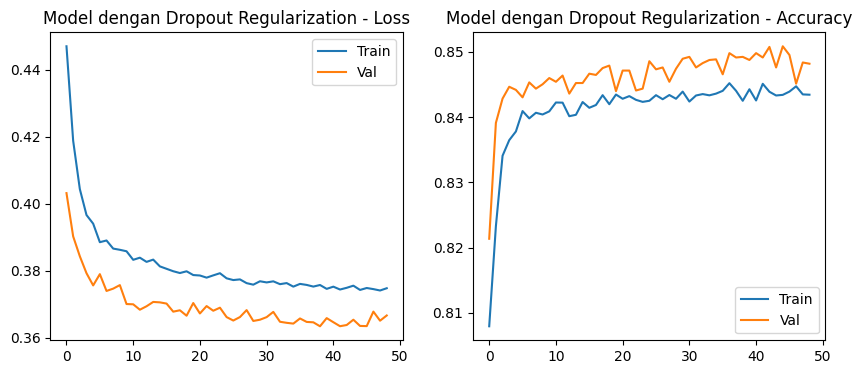

328/328 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
              precision    recall  f1-score   support

           0       0.86      0.96      0.91      8244
           1       0.76      0.42      0.54      2234

    accuracy                           0.85     10478
   macro avg       0.81      0.69      0.73     10478
weighted avg       0.84      0.85      0.83     10478



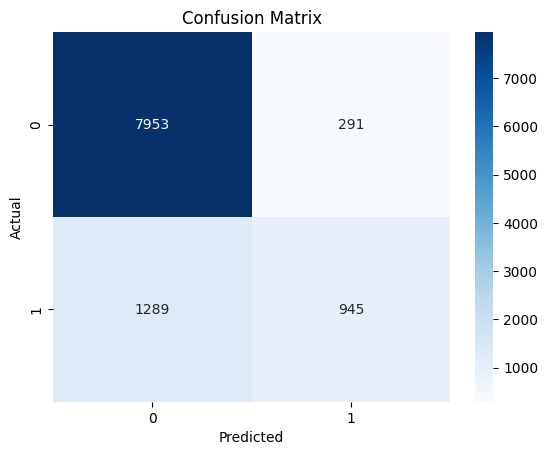

In [ ]:
model_dropout = Sequential([
    Dense(64, activation='relu', input_shape=(X_train.shape[1],)),
    Dropout(0.3),
    Dense(32, activation='relu'),
    Dropout(0.3),
    Dense(1, activation='sigmoid')
])

model_dropout.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
history_dropout = model_dropout.fit(
    X_train, y_train, validation_data=(X_test, y_test),
    epochs=100, batch_size=32, callbacks=[es], verbose=1)

plot_training(history_dropout, "Model dengan Dropout Regularization")
evaluate_model(model_dropout, X_test, y_test)


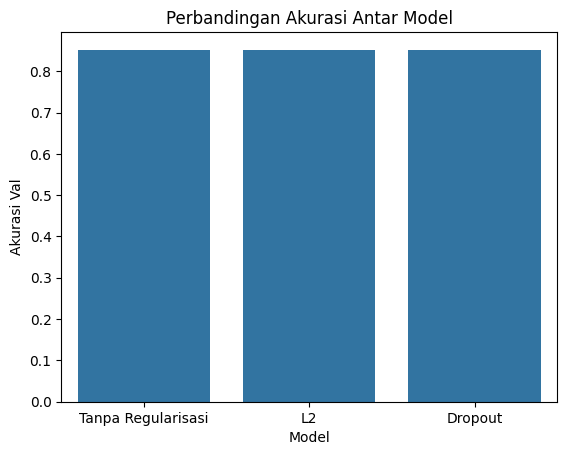

,Model,Akurasi Val
0,Tanpa Regularisasi,0.852071
1,L2,0.850639
2,Dropout,0.850830


In [ ]:
results = pd.DataFrame({
    'Model': ['Tanpa Regularisasi', 'L2', 'Dropout'],
    'Akurasi Val': [
        max(history_plain.history['val_accuracy']),
        max(history_l2.history['val_accuracy']),
        max(history_dropout.history['val_accuracy'])
    ]
})
sns.barplot(x='Model', y='Akurasi Val', data=results)
plt.title("Perbandingan Akurasi Antar Model")
plt.show()

results


/tmp/ipython-input-2886934188.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Model', y='Akurasi Validasi (%)', data=results, palette='viridis')


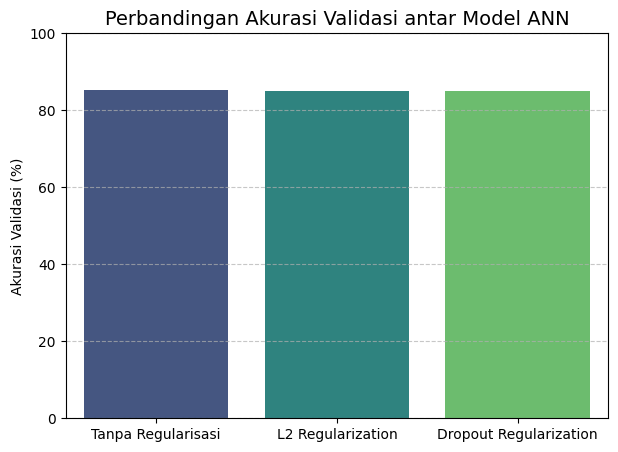

,Model,Akurasi Validasi (%)
0,Tanpa Regularisasi,85.21
1,L2 Regularization,85.06
2,Dropout Regularization,85.08


In [ ]:
# Buat DataFrame hasil
results = pd.DataFrame({
    'Model': ['Tanpa Regularisasi', 'L2 Regularization', 'Dropout Regularization'],
    'Akurasi Validasi (%)': [
        max(history_plain.history['val_accuracy']) * 100,
        max(history_l2.history['val_accuracy']) * 100,
        max(history_dropout.history['val_accuracy']) * 100
    ]
})

# Format 2 angka di belakang koma
results['Akurasi Validasi (%)'] = results['Akurasi Validasi (%)'].round(2)

# Visualisasi
plt.figure(figsize=(7,5))
sns.barplot(x='Model', y='Akurasi Validasi (%)', data=results, palette='viridis')
plt.title("Perbandingan Akurasi Validasi antar Model ANN", fontsize=14)
plt.ylabel("Akurasi Validasi (%)")
plt.xlabel("")
plt.ylim(0, 100)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# Tampilkan tabel hasil
display(results)
